In [1]:
import pickle
import os
import sys
import glob
# import torch
import numpy as np 
import pandas as pd
import scipy.io
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from scipy import signal
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from statistics import mean
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from scipy.stats import ranksums
from scipy.stats import pearsonr

# jupyter notebook display setting for all data structures
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
np.set_printoptions(threshold=np.inf)

In [2]:
# load the dictionary of dictionaries from a pickle file
with open('../../DNAbreathing/data/gcPBM_data/panset.pkl', 'rb') as handle:
    panset = pickle.load(handle)

# load the new feature dictionaries
with open('../../DNAbreathing/data/gcPBM_features/compiled_bubble_data/mad.pkl', 'rb') as handle:
    mad_features = pickle.load(handle)
with open('../../DNA-breathing/data/gcPBM_features/compiled_bubble_data/max.pkl', 'rb') as handle:
    max_features = pickle.load(handle)
with open('../../DNA-breathing/data/gcPBM_features/compiled_bubble_data/myc.pkl', 'rb') as handle:
    myc_features = pickle.load(handle)

In [3]:
mad_data = panset['mad']
max_data = panset['max']
myc_data = panset['myc']

In [4]:
# collapse the train and test partitions into one
mad = {}
for key in mad_data.keys():
    data = mad_data[key]
    for key in data.keys():
        mad[key] = data[key]
mad_data = mad.copy()
max = {}
for key in max_data.keys():
    data = max_data[key]
    for key in data.keys():
        max[key] = data[key]
max_data = max.copy()
myc = {}
for key in myc_data.keys():
    data = myc_data[key]
    for key in data.keys():
        myc[key] = data[key]
myc_data = myc.copy()

In [5]:
# replace the old feature dictionaries with the new ones
y_slice = 10
z_slice = 6
mad = {}
for key in mad_data.keys():
    data = mad_data[key]
    features = mad_features[str(key)]
    mad[key] = {'seq': data['seq'], 'label': data['label'], 'bubble': features['bubbles'][4:40,y_slice,z_slice]/80000, 'flipping': features['flip'][4:40]/80000, 'coords': features['coord'][4:40]/80000, 'coordssquared': features['coord_squared'][4:40]/80000}
mad_data = mad.copy()
max = {}
for key in max_data.keys():
    data = max_data[key]
    features = max_features[str(key)]
    max[key] = {'seq': data['seq'], 'label': data['label'], 'bubble': features['bubbles'][4:40,y_slice,z_slice]/80000, 'flipping': features['flip'][4:40]/80000, 'coords': features['coord'][4:40]/80000, 'coordssquared': features['coord_squared'][4:40]/80000}
max_data = max.copy()
myc = {}
for key in myc_data.keys():
    data = myc_data[key]
    features = myc_features[str(key)]
    myc[key] = {'seq': data['seq'], 'label': data['label'], 'bubble': features['bubbles'][4:40,y_slice,z_slice]/80000, 'flipping': features['flip'][4:40]/80000, 'coords': features['coord'][4:40]/80000, 'coordssquared': features['coord_squared'][4:40]/80000}
myc_data = myc.copy()

In [6]:
# extract the sequence ids from the data
mad_ids = [seq for seq in mad_data.keys()]
max_ids = [seq for seq in max_data.keys()]
myc_ids = [seq for seq in myc_data.keys()]

In [7]:
agnosticset = {}
for tf in [mad_data, max_data, myc_data]:
    if tf == mad_data:
        name = 'mad'
    elif tf == max_data:
        name = 'max'
    else:
        name = 'myc'
    for seq_id in tf.keys():
        agnosticset[f'{name}_{seq_id}'] = tf[seq_id]['bubble']

# bubble_binary Determination

In [8]:
# flatten all the bubble values for each sequence in each tf dictionary
mad_bubble = []
for i in mad_ids:
    mad_bubble.append(mad_data[i]['bubble'].flatten())
# flatten mad_bubble
mad_bubble = [item for sublist in mad_bubble for item in sublist]
mad_bubble = np.array(mad_bubble)
mad_percentile = np.percentile(mad_bubble, 95)
max_bubble = []
for i in max_ids:
    max_bubble.append(max_data[i]['bubble'].flatten())
# flatten max_bubble
max_bubble = [item for sublist in max_bubble for item in sublist]
max_bubble = np.array(max_bubble)
max_percentile = np.percentile(max_bubble, 95)
myc_bubble = []
for i in myc_ids:
    myc_bubble.append(myc_data[i]['bubble'].flatten())
# flatten myc_bubble
myc_bubble = [item for sublist in myc_bubble for item in sublist]
myc_bubble = np.array(myc_bubble)
myc_percentile = np.percentile(myc_bubble, 95)

print(f"MAD 95th percentile bubble value: {mad_percentile}")
print(f"MAX 95th percentile bubble value: {max_percentile}")
print(f"MYC 95th percentile bubble value: {myc_percentile}")

MAD 95th percentile bubble value: 0.000140875
MAX 95th percentile bubble value: 0.000149125
MYC 95th percentile bubble value: 0.0001425


In [9]:
for tf in [mad_data, max_data, myc_data]:
    if tf == mad_data:
        name = 'mad'
        value_set = mad_percentile
    elif tf == max_data:
        name = 'max'
        value_set = max_percentile
    else:
        name = 'myc'
        value_set = myc_percentile
    arrays = 0
    for bubble in agnosticset.keys():
        if name in bubble:
            if np.max(agnosticset[bubble]) > value_set:
                arrays += 1

    print(f'TF: {name}')
    print(f'Total arrays: {len(tf.keys())}')
    print(f'Arrays with a maximum value greater than {value_set:.4f}: {arrays}')
    print(f'Percentage of arrays with a maximum value greater than {value_set:.4f}: {arrays/len(tf.keys())*100:.2f}%')

TF: mad
Total arrays: 7534
Arrays with a maximum value greater than 0.0001: 1266
Percentage of arrays with a maximum value greater than 0.0001: 16.80%
TF: max
Total arrays: 8568
Arrays with a maximum value greater than 0.0001: 1361
Percentage of arrays with a maximum value greater than 0.0001: 15.88%
TF: myc
Total arrays: 6926
Arrays with a maximum value greater than 0.0001: 1186
Percentage of arrays with a maximum value greater than 0.0001: 17.12%


In [10]:
for tf in [mad_data, max_data, myc_data]:
    if tf == mad_data:
        name = 'mad'
        value_set = mad_percentile
    elif tf == max_data:
        name = 'max'
        value_set = max_percentile
    else:
        name = 'myc'
        value_set = myc_percentile
    arrays = 0
    for bubble in agnosticset.keys():
        if name in bubble:
            if np.max(agnosticset[bubble]) > value_set:
                tf[int(bubble.split('_')[1])]['bubble_binary'] = 1
            else:
                tf[int(bubble.split('_')[1])]['bubble_binary'] = 0

Create dictionaries that map each sequence ID to its bubble-positive or bubble-negative label. These labels will be used for downstream statistical analysis.

In [11]:
tf_label = {}
tf_bubble_binary = {}
for tf in [mad_data, max_data, myc_data]:
    if tf == mad_data:
        name = 'mad'
    elif tf == max_data:
        name = 'max'
    else:
        name = 'myc'
    tf_label[name] = []
    tf_bubble_binary[name] = []
    for seq_id in tf.keys():
        tf_label[name].append(tf[seq_id]['label'])
        tf_bubble_binary[name].append(tf[seq_id]['bubble_binary'])

In [12]:
# divide the tf_label data into bubble positive and bubble negative data
mad_label_bubble_pos = []
mad_label_bubble_neg = []
for n, i in enumerate(tf_label['mad']):
    if tf_bubble_binary['mad'][n] == 1:
        mad_label_bubble_pos.append(i)
    else:
        mad_label_bubble_neg.append(i)

max_label_bubble_pos = []
max_label_bubble_neg = []
for n, i in enumerate(tf_label['max']):
    if tf_bubble_binary['max'][n] == 1:
        max_label_bubble_pos.append(i)
    else:
        max_label_bubble_neg.append(i)

myc_label_bubble_pos = []
myc_label_bubble_neg = []
for n, i in enumerate(tf_label['myc']):
    if tf_bubble_binary['myc'][n] == 1:
        myc_label_bubble_pos.append(i)
    else:
        myc_label_bubble_neg.append(i)

# motif_seq Determination

We use the following code to parse HOMER's output into a motif sequence for our dictionary. We will probably replace this as FIMO comes in.

In [13]:
panset = {'mad': mad_data, 'max': max_data, 'myc': myc_data}

In [14]:
# find number of sequences per tf
for tf in panset.keys():
    count = 0
    for seq_id in panset[tf].keys():
        count += 1
    print(tf, count)

mad 7534
max 8568
myc 6926


In [15]:
# count and print the number of bubble positive and bubble negative sequences for each tf
for tf in panset.keys():
    bubble_pos = 0
    bubble_neg = 0
    for seq_id in panset[tf].keys():
        if panset[tf][seq_id]['bubble_binary'] == 1:
            bubble_pos += 1
        else:
            bubble_neg += 1
    print(f'{tf} bubble positive: {bubble_pos}')
    print(f'{tf} bubble negative: {bubble_neg}')

mad bubble positive: 1266
mad bubble negative: 6268
max bubble positive: 1361
max bubble negative: 7207
myc bubble positive: 1186
myc bubble negative: 5740


In [16]:
# load the fimo output files
fimo_myc = pd.read_csv('../../DNAbreathing/data/TF_fastas/meme/myc_fimo/fimo.tsv', sep='\t')
fimo_max = pd.read_csv('../../DNAbreathing/data/TF_fastas/meme/max_fimo/fimo.tsv', sep='\t')

In [17]:
# preview the fimo output for max
fimo_myc.head()

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA0147.3,MYC,6871.0,13.0,24.0,+,17.2927,2.560000e-08,0.000944,GGCCACGTGCCC
1,MA0147.3,MYC,512.0,13.0,24.0,+,17.2927,2.560000e-08,0.000944,GGCCACGTGCCC
2,MA0147.3,MYC,1165.0,13.0,24.0,+,17.2927,2.560000e-08,0.000944,GGCCACGTGCCC
3,MA0147.3,MYC,6901.0,13.0,24.0,+,17.2927,2.560000e-08,0.000944,GGCCACGTGCCC
4,MA0147.3,MYC,698.0,13.0,24.0,+,17.2927,2.560000e-08,0.000944,GGCCACGTGCCC


In [18]:
# drop NA values for the sequence_name column in the fimo output for max
fimo_max = fimo_max.dropna(subset=['sequence_name'])
# drop NA values for the sequence_name column in the fimo output for myc
fimo_myc = fimo_myc.dropna(subset=['sequence_name'])

In [19]:
# turn all the sequence_name values in the fimo output for max into int values using as type int
fimo_max['sequence_name'] = fimo_max['sequence_name'].astype(int)
# turn all the sequence_name values in the fimo output for myc into int values using as type int
fimo_myc['sequence_name'] = fimo_myc['sequence_name'].astype(int)
# turn all the sequence_name values in the fimo output for max into str values using as type str
fimo_max['sequence_name'] = fimo_max['sequence_name'].astype(str)
# turn all the sequence_name values in the fimo output for myc into str values using as type str
fimo_myc['sequence_name'] = fimo_myc['sequence_name'].astype(str)

In [20]:
for name, fimo_df in {'max': fimo_max, 'myc': fimo_myc}.items():
    sequence_counts = fimo_df['sequence_name'].value_counts()
    total_hits = len(fimo_df)
    unique_sequences = sequence_counts.size
    repeated_hits = total_hits - unique_sequences

    print(f'{name.upper()} FIMO summary')
    print(f'  Rows / motif hits: {total_hits}')
    print(f'  Columns: {fimo_df.shape[1]}')
    print(f'  Unique sequences with at least one motif hit: {unique_sequences}')
    print(f'  Extra hits beyond one per sequence: {repeated_hits}')
    print(f'  Top 5 sequences by number of motif hits:')
    print(sequence_counts.head().to_string())
    print()


MAX FIMO summary
  Rows / motif hits: 13325
  Columns: 10
  Unique sequences with at least one motif hit: 7228
  Extra hits beyond one per sequence: 6097
  Top 5 sequences by number of motif hits:
sequence_name
6582    4
5979    4
3523    4
5121    4
1114    4

MYC FIMO summary
  Rows / motif hits: 10682
  Columns: 10
  Unique sequences with at least one motif hit: 5917
  Extra hits beyond one per sequence: 4765
  Top 5 sequences by number of motif hits:
sequence_name
1248    4
6278    4
3761    4
1906    4
225     4



In [21]:
# count the instances of each value of strand in the rows of the fimo output
print('fimo_max')
print(fimo_max['strand'].value_counts())
print('fimo_myc')
print(fimo_myc['strand'].value_counts())

fimo_max
strand
+    6672
-    6653
Name: count, dtype: int64
fimo_myc
strand
+    5365
-    5317
Name: count, dtype: int64


In [22]:
# give a statistical summary of the p-value column of the fimo output for max
print(fimo_max['p-value'].describe())
# give a statistical summary of the p-value column of the fimo output for myc
print(fimo_myc['p-value'].describe())

count    1.332500e+04
mean     3.589104e-04
std      2.774100e-04
min      6.130000e-07
25%      1.110000e-04
50%      3.100000e-04
75%      5.530000e-04
max      1.000000e-03
Name: p-value, dtype: float64
count    1.068200e+04
mean     2.431442e-04
std      2.486313e-04
min      2.560000e-08
25%      5.300000e-05
50%      1.565000e-04
75%      3.550000e-04
max      9.980000e-04
Name: p-value, dtype: float64


In [23]:
# fimo motif_seq and p-value assignment
for tf in panset.keys():
    if tf in ['mad']:
        continue

    if tf == 'max':
        fasta = fimo_max
    elif tf == 'myc':
        fasta = fimo_myc

    for seq_id in panset[tf].keys():
        panset[tf][seq_id]['motif_seq_positive'] = np.zeros(len(panset[tf][seq_id]['seq']))
        panset[tf][seq_id]['motif_seq_negative'] = np.zeros(len(panset[tf][seq_id]['seq']))
        panset[tf][seq_id]['motif_seq'] = np.zeros(len(panset[tf][seq_id]['seq']))
        panset[tf][seq_id]['p-value_positive'] = 0
        panset[tf][seq_id]['p-value_negative'] = 0

        for fasta_id in fasta['sequence_name']:
            if fasta_id == str(seq_id):

                # =========================
                # CHANGED: get the best hit
                # (minimum p-value) for this sequence
                # =========================
                seq_hits = fasta[fasta['sequence_name'] == fasta_id]   # CHANGED
                best_idx = seq_hits['p-value'].idxmin()                # CHANGED
                best_hit = seq_hits.loc[best_idx]                      # CHANGED

                # =========================
                # CHANGED: use best_hit instead of values[0]
                # =========================
                if best_hit['strand'] == '+':                          # CHANGED
                    motif_seq = best_hit['matched_sequence']           # CHANGED
                    pos = panset[tf][seq_id]['seq'].index(motif_seq)
                    panset[tf][seq_id]['motif_seq_positive'][pos:pos+len(motif_seq)] = 1
                    panset[tf][seq_id]['p-value_positive'] = best_hit['p-value']   # CHANGED

                elif best_hit['strand'] == '-':                       # CHANGED
                    motif_seq = best_hit['matched_sequence']          # CHANGED
                    negative_strand = ''
                    for base in panset[tf][seq_id]['seq']:
                        if base == 'A':
                            negative_strand += 'T'
                        elif base == 'T':
                            negative_strand += 'A'
                        elif base == 'C':
                            negative_strand += 'G'
                        elif base == 'G':
                            negative_strand += 'C'

                    # reverse the string
                    motif_seq = motif_seq[::-1]
                    if motif_seq in negative_strand:
                        pos = negative_strand.index(motif_seq)
                        # create np.array of zeros with length of the sequence
                        # make the positions of motif_seq to len(motif_seq) + pos in panset[tf][fasta_id]['seq'] equal to 1
                        panset[tf][seq_id]['motif_seq_negative'][pos:pos+len(motif_seq)] = 1
                        panset[tf][seq_id]['p-value_negative'] = best_hit['p-value']   # CHANGED

                # motif_seq as a concatenation of motif_seq_positive and motif_seq_negative
                for i in range(len(panset[tf][seq_id]['seq'])):
                    if panset[tf][seq_id]['motif_seq_positive'][i] == 1:
                        panset[tf][seq_id]['motif_seq'][i] = 1
                    elif panset[tf][seq_id]['motif_seq_negative'][i] == 1:
                        panset[tf][seq_id]['motif_seq'][i] = 1

In [24]:
# fimo motif_binary and strong/weak assignment
for tf in panset.keys():
    if tf == 'mad':
        continue
    no_motif = 0
    strong_motifs = 0
    weak_motifs = 0
    for seq_id in panset[tf].keys():
        panset[tf][seq_id]['strong_motif_binary'] = 0
        panset[tf][seq_id]['weak_motif_binary'] = 0
        # p-value threshold of 0.0001, less than or equal to 0.0001 is strong, greater than 0.0001 is weak
        if panset[tf][seq_id]['p-value_positive'] == 0 and panset[tf][seq_id]['p-value_negative'] == 0:
            no_motif += 1
        elif 0 < panset[tf][seq_id]['p-value_positive'] <= 0.0001 or 0 < panset[tf][seq_id]['p-value_negative'] <= 0.0001:
            panset[tf][seq_id]['strong_motif_binary'] = 1
            strong_motifs += 1
        elif panset[tf][seq_id]['p-value_positive'] > 0.0001 or panset[tf][seq_id]['p-value_negative'] > 0.0001:
            panset[tf][seq_id]['weak_motif_binary'] = 1
            weak_motifs += 1
    print(f'{tf} strong motifs: {strong_motifs}')
    print(f'{tf} weak motifs: {weak_motifs}')
    print(f'{tf} no motifs: {no_motif}')

max strong motifs: 1877
max weak motifs: 5351
max no motifs: 1340
myc strong motifs: 2636
myc weak motifs: 3281
myc no motifs: 1009


In [25]:
# counts of positive, negative, strong, and weak motifs as well as the total number of motifs per tf
for tf in panset.keys():
    if tf == 'mad':
        continue
    positive_motifs = 0
    negative_motifs = 0
    strong_motifs = 0
    weak_motifs = 0
    total_motifs = 0
    total_sequences = 0
    for seq_id in panset[tf].keys():
        total_sequences += 1
        if sum(panset[tf][seq_id]['motif_seq_positive']) != 0:
            positive_motifs += 1
        if sum(panset[tf][seq_id]['motif_seq_negative']) != 0:
            negative_motifs += 1
        strong_motifs += panset[tf][seq_id]['strong_motif_binary']
        weak_motifs += panset[tf][seq_id]['weak_motif_binary']
        if sum(panset[tf][seq_id]['motif_seq_positive']) != 0 or sum(panset[tf][seq_id]['motif_seq_negative']) != 0:
            total_motifs += 1
    print(tf)
    print(f'positive motifs: {positive_motifs}')
    print(f'negative motifs: {negative_motifs}')
    print(f'strong motifs: {strong_motifs}')
    print(f'weak motifs: {weak_motifs}')
    print(f'total motifs: {total_motifs}')
    print(f'total sequences: {total_sequences}')

max
positive motifs: 3988
negative motifs: 3240
strong motifs: 1877
weak motifs: 5351
total motifs: 7228
total sequences: 8568
myc
positive motifs: 3139
negative motifs: 2778
strong motifs: 2636
weak motifs: 3281
total motifs: 5917
total sequences: 6926


In [26]:
# create a table in markdown of each tf with the counts of positive, negative, strong, and weak motifs as well as the total number of motifs, total sequences, and total bubble positive sequences
# print the header of the table
print('| TF | Strong Motifs | Weak Motifs | Total Motifs | Total Sequences | Total Bubble Positive |')
for tf in panset.keys():
    if tf == 'mad':
        continue
    strong_motifs = 0
    weak_motifs = 0
    total_motifs = 0
    total_sequences = 0
    total_bubble_positive = 0
    for seq_id in panset[tf].keys():
        total_sequences += 1
        strong_motifs += panset[tf][seq_id]['strong_motif_binary']
        weak_motifs += panset[tf][seq_id]['weak_motif_binary']
        if panset[tf][seq_id]['strong_motif_binary'] == 1 or panset[tf][seq_id]['weak_motif_binary'] == 1:
            total_motifs += 1
        if panset[tf][seq_id]['bubble_binary'] == 1:
            total_bubble_positive += 1
    print(f'| {tf} | {strong_motifs} | {weak_motifs} | {total_motifs} | {total_sequences} | {total_bubble_positive} |')

| TF | Strong Motifs | Weak Motifs | Total Motifs | Total Sequences | Total Bubble Positive |
| max | 1877 | 5351 | 7228 | 8568 | 1361 |
| myc | 2636 | 3281 | 5917 | 6926 | 1186 |


# bubble_seq Determination

In [27]:
# use the 0.03 threshold at any timepoint to create a binary array of bubble values for each sequence
for tf in panset.keys():
    if tf == 'mad':
        continue
    if tf == 'max':
        value_set = max_percentile
        print(max_percentile)
    else:
        value_set = myc_percentile
        print(myc_percentile)
    for seq_id in panset[tf].keys():
        panset[tf][seq_id]['bubble_seq'] = np.zeros(len(panset[tf][seq_id]['seq']))
        for i in range(len(panset[tf][seq_id]['bubble'])):
            if panset[tf][seq_id]['bubble'][i] > value_set:
                panset[tf][seq_id]['bubble_seq'][i] = 1
                break

0.000149125
0.0001425


# motif_binary and motif_and_bubble_binary Determination

In [28]:
for tf in panset.keys():
    if tf == 'mad':
        continue
    for seq_id in panset[tf].keys():
        panset[tf][seq_id]['strong_motif_and_bubble_binary'] = 0
        panset[tf][seq_id]['weak_motif_and_bubble_binary'] = 0
        panset[tf][seq_id]['motif_and_bubble_binary'] = 0
        if panset[tf][seq_id]['strong_motif_binary'] == 1 and panset[tf][seq_id]['bubble_binary'] == 1:
            panset[tf][seq_id]['motif_and_bubble_binary'] = 1
            panset[tf][seq_id]['strong_motif_and_bubble_binary'] = 1
        elif panset[tf][seq_id]['weak_motif_binary'] == 1 and panset[tf][seq_id]['bubble_binary'] == 1:
            panset[tf][seq_id]['motif_and_bubble_binary'] = 1
            panset[tf][seq_id]['weak_motif_and_bubble_binary'] = 1

Now we try to do the Fischer test

In [29]:
affinity = {}
for tf in panset.keys():
    affinity[tf] = {}
    for seq_id in panset[tf].keys():
        affinity[tf][seq_id] = panset[tf][seq_id]['label']

# keep only the seq_ids in affinity that have the top 20% binding affinity

# Calculate the 20th percentile of binding affinity for each TF and part
# percentile_cutoff = 20
# for tf in affinity.keys():
#     seq_ids = list(affinity[tf].keys())
#     binding_affinities = [affinity[tf][seq_id] for seq_id in seq_ids]
#     cutoff_value = np.percentile(binding_affinities, 100 - percentile_cutoff)

#     # Keep only the seq_ids in affinity that have the top 20% binding affinity
#     top_20_seq_ids = [seq_id for seq_id in seq_ids if affinity[tf][seq_id] >= cutoff_value]
#     affinity[tf] = {seq_id: affinity[tf][seq_id] for seq_id in top_20_seq_ids}

In [30]:
fischer = {}

for tf in panset.keys():
    if tf == 'mad':
        continue
    fischer[tf] = {}
    L = 0
    B = 0
    M = 0
    x = 0
    for seq_id in affinity[tf].keys():
        if seq_id in panset[tf].keys():
            L += 36
            if panset[tf][seq_id]['bubble_binary'] == 0:
                for i in range(36):
                    if panset[tf][seq_id]['strong_motif_binary'] == 1 and (panset[tf][seq_id]['motif_seq_positive'][i] == 1 or panset[tf][seq_id]['motif_seq_negative'][i] == 1):
                        M += 1
            else:
                for i in range(36):
                    if panset[tf][seq_id]['bubble_seq'][i] == 1:
                        B += 1
                    if panset[tf][seq_id]['strong_motif_binary'] == 1 and (panset[tf][seq_id]['motif_seq_positive'][i] == 1 or panset[tf][seq_id]['motif_seq_negative'][i] == 1):
                        M += 1
                    if panset[tf][seq_id]['strong_motif_binary'] == 1 and (panset[tf][seq_id]['bubble_seq'][i] == 1 and (panset[tf][seq_id]['motif_seq_positive'][i] == 1 or panset[tf][seq_id]['motif_seq_negative'][i] == 1)):
                        x += 1
    fischer[tf]['L'] = L
    fischer[tf]['B'] = B
    fischer[tf]['M'] = M
    fischer[tf]['x'] = x
                

In [31]:
fischer

{'max': {'L': 308448, 'B': 1361, 'M': 18770, 'x': 46},
 'myc': {'L': 249336, 'B': 1186, 'M': 31632, 'x': 85}}

In [32]:
def conduct_fisher_test(fischer_scores):
    for tf, data in fischer_scores.items():
        L = data['L']
        B = data['B']
        M = data['M']
        x = data['x']

        # Contingency table
        contingency_table = [[x, M - x], [B - x, L - M - B + x]]

        # Perform Fisher's exact test
        odds_ratio, p_value = fisher_exact(contingency_table)

        # Print results
        print(f"TF: {tf}")
        print(f"Contingency Table:")
        print(f"         | Bubble+ | Bubble-")
        print(f"Motif+   |   {x}   |   {M - x}")
        print(f"Motif-   |   {B - x}   |   {L - M - B + x}")
        print(f"Odds Ratio: {odds_ratio}")
        print(f"P-value: {p_value}\n")

In [33]:
conduct_fisher_test(fischer)

TF: max
Contingency Table:
         | Bubble+ | Bubble-
Motif+   |   46   |   18724
Motif-   |   1315   |   288363
Odds Ratio: 0.5387322587955679
P-value: 8.510400968969282e-06

TF: myc
Contingency Table:
         | Bubble+ | Bubble-
Motif+   |   85   |   31547
Motif-   |   1101   |   216603
Odds Ratio: 0.5300758377124949
P-value: 1.0090991397916577e-09



Now we perform the linear test

In [34]:
import statsmodels.api as sm
from sklearn.metrics import r2_score
from scipy.stats import f

def calculate_statistics(X, y):
    # Add a constant term for the intercept
    X = sm.add_constant(X)
    
    # Fit the model using statsmodels
    model = sm.OLS(y, X).fit()
    
    # Get predicted values
    y_pred = model.predict(X)
    
    # Residuals
    residuals = y - y_pred
    
    # R-squared
    r_squared = r2_score(y, y_pred)
    
    # Degrees of freedom
    n = X.shape[0]
    p = X.shape[1] - 1
    df_residual = n - p - 1
    
    # Mean squared error
    mse = np.mean(residuals**2)
    
    # F-statistic and p-value
    ssr = np.sum(residuals**2)
    sst = np.sum((y - np.mean(y))**2)
    f_statistic = (sst - ssr) / p / mse
    p_value = 1 - f.cdf(f_statistic, p, df_residual)
    
    # Create a DataFrame to store the results
    summary_df = model.summary2().tables[1]
    
    # Add R-squared, F-statistic, and p-value as additional rows
    summary_df.loc['R-squared'] = [r_squared] + [''] * (len(summary_df.columns) - 1)
    summary_df.loc['F-statistic'] = [f_statistic] + [''] * (len(summary_df.columns) - 1)
    summary_df.loc['P-value (F-statistic)'] = [p_value] + [''] * (len(summary_df.columns) - 1)
    
    return summary_df

In [35]:
def perform_linear_regression(data, x_columns, y_column):
    X = sm.add_constant(data[x_columns])
    y = data[y_column]

    model = sm.OLS(y, X).fit()
    return model

# Loop through the panset dictionary for each TF separately
data = {}
models = {}
summaries_both = {}

In [36]:
for tf in panset.keys():
    if tf == 'mad':
        continue
    data[tf] = []
    for seq_id in affinity[tf].keys():
        if seq_id in panset[tf].keys():
            data_point = {
                'motif_binary': panset[tf][seq_id]['strong_motif_binary'],
                'bubble_binary': panset[tf][seq_id]['bubble_binary'],
                'motif_and_bubble_binary': panset[tf][seq_id]['strong_motif_and_bubble_binary'],
                'binding_affinity': panset[tf][seq_id]['label']
            }
            # Append the data point to the appropriate list based on the presence of motif and bubble
            data[tf].append(data_point)

    # Create pandas DataFrame for each TF
    df = pd.DataFrame(data[tf])

    # Perform linear regression for each case
    model_motif = perform_linear_regression(df, ['motif_binary'], 'binding_affinity')
    model_bubble = perform_linear_regression(df, ['bubble_binary'], 'binding_affinity')
    model_double = perform_linear_regression(df, ['motif_binary', 'bubble_binary'], 'binding_affinity')
    model_triple = perform_linear_regression(df, ['motif_binary', 'bubble_binary', 'motif_and_bubble_binary'], 'binding_affinity')

    # Store the models for each TF
    models[tf] = {
        'motif_only': model_motif,
        'bubble_only': model_bubble,
        'both_features': model_double,
        'all_features': model_triple
        }
    
    summaries_both[tf] = calculate_statistics(df[['motif_binary', 'bubble_binary']], df['binding_affinity'])

In [37]:
# print summaries for the both features models only
for tf in summaries_both.keys():
    print(tf)
    print(summaries_both[tf].to_markdown())

max
|                       |        Coef. | Std.Err.              | t                  | P>|t|                | [0.025              | 0.975]              |
|:----------------------|-------------:|:----------------------|:-------------------|:---------------------|:--------------------|:--------------------|
| const                 |    3.99134   | 0.0016891432388664322 | 2362.934741670074  | 0.0                  | 3.988024114950126   | 3.9946463705990833  |
| motif_binary          |    0.415901  | 0.003342867280376359  | 124.41453450384209 | 0.0                  | 0.40934845110988594 | 0.42245410208241263 |
| bubble_binary         |    0.0559322 | 0.0037826003817379387 | 14.786714657828115 | 7.12661986803141e-49 | 0.04851742417062077 | 0.06334704084808043 |
| R-squared             |    0.644649  |                       |                    |                      |                     |                     |
| F-statistic           | 7771.68      |                       |              

In [38]:
# Sort affinity by highest to lowest and save the top 20 keys in a list
affinities = {}
highest_affinity = {}
lowest_affinity = {}
for tf in panset.keys():
    if tf == 'mad':
        continue
    affinities[tf] = {}
    highest_affinity[tf] = []
    for seq_id in panset[tf].keys():
        affinities[tf][seq_id] = panset[tf][seq_id]['label']
    highest_affinity[tf] = sorted(affinity[tf].items(), key=lambda item: item[1], reverse=True)
    lowest_affinity[tf] = sorted(affinity[tf].items(), key=lambda item: item[1], reverse=False)

In [39]:
# previewing the highest affinity sequences for each TF
for tf in panset.keys():
    if tf == 'mad':
        continue
    seq_count = 0
    for seq_id in panset[tf].keys():
        seq_count += 1
    print(f'TF = {tf}, total number of sequences = {seq_count}')
    count = 0
    for n, seq_id_p in enumerate(highest_affinity[tf]):
        for seq_id in panset[tf].keys():
            if seq_id_p[0] == seq_id and panset[tf][seq_id]['bubble_binary'] == 1:
                count += 1
                DNA_sequence = panset[tf][seq_id]['seq']
                Bubble_sequence = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['bubble_seq']]
                Bubble_sequence = ''.join(Bubble_sequence)
                Motif_positive = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq_positive']]
                Motif_negative = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq_negative']]
                Motif_positive = ''.join(Motif_positive)
                Motif_negative = ''.join(Motif_negative)
                Motif_sequence = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq']]
                Motif_sequence = ''.join(Motif_sequence)
                # print the sequence id, DNA sequence, bubble sequence, and motif sequence
                print(f'{count}.\tSequence ID    = {seq_id}')
                print(f'{count}.\tDNA_sequence    = {DNA_sequence}')
                print(f'{count}.\tBubble_sequence = {Bubble_sequence}')
                print(f'{count}.\tMotif_positive  = {Motif_positive}')
                print(f'{count}.\tMotif_negative  = {Motif_negative}')
                print(f'{count}.\tMotif_sequence  = {Motif_sequence}')
        if count == 20:
            break

TF = max, total number of sequences = 8568
1.	Sequence ID    = 4831
1.	DNA_sequence    = TGTGGCTTATCAAACCACGTGGTTTATCAAAATAAT
1.	Bubble_sequence = ---------+--------------------------
1.	Motif_positive  = -------------++++++++++-------------
1.	Motif_negative  = ------------------------------------
1.	Motif_sequence  = -------------++++++++++-------------
2.	Sequence ID    = 373
2.	DNA_sequence    = TTACGCTCTTTCTACCACGTGGTGCTAATTGAAGGG
2.	Bubble_sequence = -----------+------------------------
2.	Motif_positive  = -------------++++++++++-------------
2.	Motif_negative  = ------------------------------------
2.	Motif_sequence  = -------------++++++++++-------------
3.	Sequence ID    = 2746
3.	DNA_sequence    = AAGAAAAAGAAGTACCACGTGGTAAACAGAATACCT
3.	Bubble_sequence = ----------------------+-------------
3.	Motif_positive  = -------------++++++++++-------------
3.	Motif_negative  = ------------------------------------
3.	Motif_sequence  = -------------++++++++++-------------
4.	Sequence I

In [40]:
# previewing the lowest affinity sequences for each TF
for tf in panset.keys():
    if tf == 'mad':
        continue
    seq_count = 0
    for seq_id in panset[tf].keys():
        seq_count += 1
    print(f'TF = {tf}, total number of sequences = {seq_count}')
    count = 0
    for n, seq_id_p in enumerate(lowest_affinity[tf]):
        for seq_id in panset[tf].keys():
            if seq_id_p[0] == seq_id and panset[tf][seq_id]['bubble_binary'] == 1:
                count += 1
                DNA_sequence = panset[tf][seq_id]['seq']
                Bubble_sequence = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['bubble_seq']]
                Bubble_sequence = ''.join(Bubble_sequence)
                Motif_positive = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq_positive']]
                Motif_negative = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq_negative']]
                Motif_positive = ''.join(Motif_positive)
                Motif_negative = ''.join(Motif_negative)
                Motif_sequence = ['-' if i == 0 else '+' for i in panset[tf][seq_id]['motif_seq']]
                Motif_sequence = ''.join(Motif_sequence)
                print(f'{count}.\tDNA_sequence    = {DNA_sequence}')
                print(f'{count}.\tBubble_sequence = {Bubble_sequence}')
                print(f'{count}.\tMotif_positive  = {Motif_positive}')
                print(f'{count}.\tMotif_negative  = {Motif_negative}')
                print(f'{count}.\tMotif_sequence  = {Motif_sequence}')
        if count == 20:
            break

TF = max, total number of sequences = 8568
1.	DNA_sequence    = TGTGCGGGACGCGGGCACGCGCGGGGAGCGAGTTCT
1.	Bubble_sequence = --------------------------------+---
1.	Motif_positive  = ------------------------------------
1.	Motif_negative  = -------------++++++++++-------------
1.	Motif_sequence  = -------------++++++++++-------------
2.	DNA_sequence    = CAGGGTTCCTGCAGGCGCGTGCCTTGGGTGGCCCCG
2.	Bubble_sequence = +-----------------------------------
2.	Motif_positive  = ------------------------------------
2.	Motif_negative  = -------------++++++++++-------------
2.	Motif_sequence  = -------------++++++++++-------------
3.	DNA_sequence    = CTCGCCTCAGCCGCGCGCGTGCCTCCTGCCCCGACA
3.	Bubble_sequence = --+---------------------------------
3.	Motif_positive  = -------------++++++++++-------------
3.	Motif_negative  = ------------------------------------
3.	Motif_sequence  = -------------++++++++++-------------
4.	DNA_sequence    = CTCTTCAATAGAAGGCACGCGAATGGACTCTAAGGG
4.	Bubble_sequence = --------

In [41]:
# pick the top x% of sequences with highest affinity
x = 0.1
positive_sequences = {}
negative_sequences = {}
for tf in panset.keys():
    if tf == 'mad':
        continue
    positive_sequences[tf] = []
    negative_sequences[tf] = []
    total_seq_count = len(highest_affinity[tf])
    top_x_percent = int(total_seq_count * x)
    rest_of_sequences = total_seq_count - top_x_percent
    for n, seq_id_p in enumerate(highest_affinity[tf]):
        if n < top_x_percent:
            for seq_id in panset[tf].keys():
                if seq_id_p[0] == seq_id and panset[tf][seq_id]['bubble_binary'] == 1 and panset[tf][seq_id]['strong_motif_binary'] == 1:
                    positive_sequences[tf].append(seq_id)
        else:
            for seq_id in panset[tf].keys():
                if seq_id_p[0] == seq_id and panset[tf][seq_id]['bubble_binary'] == 1 and panset[tf][seq_id]['strong_motif_binary'] == 1:
                    negative_sequences[tf].append(seq_id)

In [42]:
# distance between bubble and motif sequences, the algorithm
for tf in panset.keys():
    if tf == 'mad':
        continue
    for seq_id_p in positive_sequences[tf]:
        for seq_id in panset[tf].keys():
            if seq_id_p == seq_id:
                Bubble_sequence = panset[tf][seq_id]['bubble_seq']
                Motif_sequence = panset[tf][seq_id]['motif_seq']
                # we will calculate the distance between instances of the bubble and motif in the sequence
                flip = 0
                distances = []
                distance = 0
                for i in range(len(Bubble_sequence)):
                    if Bubble_sequence[i] == 1 and Motif_sequence[i] == 1:
                        distance = 0
                        distances.append(distance)
                        break
                    if flip == 0:
                        if Bubble_sequence[i] == 1 and Motif_sequence[i] == 0:
                            flip = 1
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 1:
                            flip = 2
                    elif flip == 1:
                        if Bubble_sequence[i] == 0 and Motif_sequence[i] == 1:
                            distance += 1
                            distances.append(distance)
                            distance = 0
                            flip = 2
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 0:
                            distance += 1
                    elif flip == 2:
                        if Bubble_sequence[i] == 1 and Motif_sequence[i] == 0:
                            distance += 1
                            distances.append(distance)
                            distance = 0
                            flip = 1
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 0:
                            distance += 1
                panset[tf][seq_id]['min_distance'] = min(distances)

# now for the negative sequences
for tf in panset.keys():
    if tf == 'mad':
        continue
    for seq_id_p in negative_sequences[tf]:
        for seq_id in panset[tf].keys():
            if seq_id_p == seq_id:
                Bubble_sequence = panset[tf][seq_id]['bubble_seq']
                Motif_sequence = panset[tf][seq_id]['motif_seq']
                # we will calculate the distance between instances of the bubble and motif in the sequence
                flip = 0
                distances = []
                distance = 0
                for i in range(len(Bubble_sequence)):
                    if Bubble_sequence[i] == 1 and Motif_sequence[i] == 1:
                        distance = 0
                        distances.append(distance)
                        break
                    if flip == 0:
                        if Bubble_sequence[i] == 1 and Motif_sequence[i] == 0:
                            flip = 1
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 1:
                            flip = 2
                    elif flip == 1:
                        if Bubble_sequence[i] == 0 and Motif_sequence[i] == 1:
                            distance += 1
                            distances.append(distance)
                            distance = 0
                            flip = 2
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 0:
                            distance += 1
                    elif flip == 2:
                        if Bubble_sequence[i] == 1 and Motif_sequence[i] == 0:
                            distance += 1
                            distances.append(distance)
                            distance = 0
                            flip = 1
                        elif Bubble_sequence[i] == 0 and Motif_sequence[i] == 0:
                            distance += 1
                panset[tf][seq_id]['min_distance'] = min(distances)

In [43]:
# delete max
del(max)

# xx

In [44]:
for tf in panset.keys():
    if tf == 'mad':
        continue
    for seq_id in panset[tf].keys():
        flip = []
        coord = []
        coordsq = []
        for i in range(36):
            if panset[tf][seq_id]['motif_seq'][i] == 1:
                flip.append(panset[tf][seq_id]['flipping'][i])
                coord.append(panset[tf][seq_id]['coords'][i])
                coordsq.append(panset[tf][seq_id]['coordssquared'][i])
            else:
                flip.append(0)
                coord.append(0)
                coordsq.append(0)
        # append the average feature value to the dictionary
        panset[tf][seq_id]['motif_flip'] = sum(flip) / len(flip)
        panset[tf][seq_id]['motif_coord'] = sum(coord) / len(coord)
        panset[tf][seq_id]['motif_coordsq'] = sum(coordsq) / len(coordsq)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import Normalize
#from matplotlib.cm import get_cmap
import matplotlib as mpl

# -----------------------------
# style
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------
# feature functions
# -----------------------------
def gc_content(seq):
    seq = seq.upper()
    return (seq.count("G") + seq.count("C")) / len(seq)

def count_tpa(seq):
    seq = seq.upper()
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == "TA")

def count_ypr(seq):
    seq = seq.upper()
    ypr_set = {"CA", "CG", "TA", "TG"}   # Y=C/T, R=A/G
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] in ypr_set)

# -----------------------------
# helper: bin averages
# -----------------------------
def bin_average_points(x, y, feat, bins):
    bin_idx = np.digitize(feat, bins, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, len(bins) - 2)

    mean_x = np.full(len(bins) - 1, np.nan)
    mean_y = np.full(len(bins) - 1, np.nan)

    for i in range(len(bins) - 1):
        mask = bin_idx == i
        if np.sum(mask) > 0:
            mean_x[i] = x[mask].mean()
            mean_y[i] = y[mask].mean()

    valid = ~np.isnan(mean_x) & ~np.isnan(mean_y)
    return mean_x[valid], mean_y[valid], np.arange(len(bins) - 1)[valid]

# -----------------------------
# helper: x-axis padding
# -----------------------------
def pad_xlim(xlim, frac=0.04):
    lo, hi = xlim
    pad = (hi - lo) * frac
    return lo - pad, hi + pad

# -----------------------------
# main plotting function
# -----------------------------
def plot_feature_vs_flip(
    panset,
    feature_func,
    feature_name,
    feature_label,
    bins,
    bin_ticklabels=None,
    cmap_name="viridis",
    save_prefix="flip_profile_combined"
):
    plot_data = {}
    all_feat = []

    # -----------------------------
    # collect raw data
    # -----------------------------
    for tf in ["max", "myc"]:
        motif_flip = []
        binding_affinity = []
        feat_values = []

        for seq_id in panset[tf].keys():
            if panset[tf][seq_id]["strong_motif_binary"] == 1:
                motif_flip.append(panset[tf][seq_id]["motif_flip"])
                binding_affinity.append(panset[tf][seq_id]["label"])

                seq = panset[tf][seq_id]["seq"]
                feat_values.append(feature_func(seq))

        motif_flip = np.array(motif_flip)
        binding_affinity = np.array(binding_affinity)
        feat_values = np.array(feat_values)

        corr, pval = pearsonr(motif_flip, binding_affinity)

        plot_data[tf] = {
            "x": motif_flip,
            "y": binding_affinity,
            "feat": feat_values,
            "r_raw": corr,
            "p_raw": pval
        }

        all_feat.extend(feat_values)

    # -----------------------------
    # color scales
    # -----------------------------
    norm_cont = Normalize(vmin=min(all_feat), vmax=max(all_feat))
    cmap_cont = cmap_name
    #cmap_disc = get_cmap(cmap_name, len(bins) - 1)
    cmap_disc = mpl.colormaps.get_cmap(cmap_name).resampled(len(bins) - 1)
    
    # -----------------------------
    # precompute binned data
    # -----------------------------
    for tf in ["max", "myc"]:
        x = plot_data[tf]["x"]
        y = plot_data[tf]["y"]
        feat = plot_data[tf]["feat"]

        bx, by, bcolor = bin_average_points(x, y, feat, bins)

        if len(bx) > 1:
            r_bin, p_bin = pearsonr(bx, by)
        else:
            r_bin, p_bin = np.nan, np.nan

        plot_data[tf]["bx"] = bx
        plot_data[tf]["by"] = by
        plot_data[tf]["bcolor"] = bcolor
        plot_data[tf]["r_bin"] = r_bin
        plot_data[tf]["p_bin"] = p_bin

    # -----------------------------
    # shared x-limits by TF column
    # -----------------------------
    xlim_max = pad_xlim((
        min(plot_data["max"]["x"].min(), plot_data["max"]["bx"].min()),
        max(plot_data["max"]["x"].max(), plot_data["max"]["bx"].max())
    ))
    xlim_myc = pad_xlim((
        min(plot_data["myc"]["x"].min(), plot_data["myc"]["bx"].min()),
        max(plot_data["myc"]["x"].max(), plot_data["myc"]["bx"].max())
    ))

    # -----------------------------
    # figure with dedicated colorbar columns
    # -----------------------------
    fig = plt.figure(figsize=(10, 7.6))
    gs = fig.add_gridspec(
        2, 4,
        width_ratios=[1, 1, 0.05, 0.05],
        hspace=0.2,
        wspace=0.35
    )

    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    axD = fig.add_subplot(gs[1, 1])
    
    import matplotlib.ticker as ticker
    for ax in [axA, axB, axC, axD]:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

    cax_top = fig.add_subplot(gs[0, 2])
    cax_bottom = fig.add_subplot(gs[1, 2])

    spare1 = fig.add_subplot(gs[0, 3]); spare1.axis("off")
    spare2 = fig.add_subplot(gs[1, 3]); spare2.axis("off")

    # -----------------------------
    # A: MAX raw scatter
    # -----------------------------
    d = plot_data["max"]
    sc1 = axA.scatter(
        d["x"], d["y"],
        c=d["feat"], cmap=cmap_cont, norm=norm_cont,
        s=12, alpha=0.85, linewidths=0, rasterized=True
    )
    m, b = np.polyfit(d["x"], d["y"], 1)
    xline = np.linspace(*xlim_max, 200)
    axA.plot(xline, m * xline + b, color="red", linestyle="--", linewidth=1.1)
    axA.set_title("MAX", pad=6)
    axA.set_xlabel("Flipping profile")
    axA.set_ylabel("Binding affinity")
    axA.set_xlim(xlim_max)
    axA.spines["top"].set_visible(False)
    axA.spines["right"].set_visible(False)
    axA.text(-0.19, 1.10, "a", transform=axA.transAxes, fontsize=16, fontweight="bold", va="top")
    axA.text(
        0.97, 0.05,
        f"$r$ = {d['r_raw']:.2f}\n$p$ = {d['p_raw']:.2e}",
        transform=axA.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
    )

    # -----------------------------
    # B: MYC raw scatter
    # -----------------------------
    d = plot_data["myc"]
    axB.scatter(
        d["x"], d["y"],
        c=d["feat"], cmap=cmap_cont, norm=norm_cont,
        s=12, alpha=0.85, linewidths=0, rasterized=True
    )
    m, b = np.polyfit(d["x"], d["y"], 1)
    xline = np.linspace(*xlim_myc, 200)
    axB.plot(xline, m * xline + b, color="red", linestyle="--", linewidth=1.1)
    axB.set_title("MYC", pad=6)
    axB.set_xlabel("Flipping profile")
    axB.set_ylabel("Binding affinity")
    axB.set_xlim(xlim_myc)
    axB.spines["top"].set_visible(False)
    axB.spines["right"].set_visible(False)
    axB.text(
        0.97, 0.05,
        f"$r$ = {d['r_raw']:.2f}\n$p$ = {d['p_raw']:.2e}",
        transform=axB.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
    )

    # -----------------------------
    # C: MAX binned averages
    # -----------------------------
    d = plot_data["max"]
    sc2 = axC.scatter(
        d["bx"], d["by"],
        c=d["bcolor"], cmap=cmap_disc,
        s=80, edgecolor="black", linewidth=0.5
    )
    m, b = np.polyfit(d["bx"], d["by"], 1)
    xline = np.linspace(*xlim_max, 100)
    axC.plot(xline, m * xline + b, color="red", linestyle="--", linewidth=1.2)
    #axC.set_title("MAX", pad=6)
    axC.set_xlabel("Mean Flipping Profile")
    axC.set_ylabel("Mean Binding Affinity")
    axC.set_xlim(xlim_max)
    axC.spines["top"].set_visible(False)
    axC.spines["right"].set_visible(False)
    axC.text(-0.19, 1.10, "b", transform=axC.transAxes, fontsize=16, fontweight="bold", va="top")
    axC.text(
        0.97, 0.05,
        f"$r$ = {d['r_bin']:.2f}\n$p$ = {d['p_bin']:.2e}",
        transform=axC.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
    )

    # -----------------------------
    # D: MYC binned averages
    # -----------------------------
    d = plot_data["myc"]
    axD.scatter(
        d["bx"], d["by"],
        c=d["bcolor"], cmap=cmap_disc,
        s=80, edgecolor="black", linewidth=0.5
    )
    m, b = np.polyfit(d["bx"], d["by"], 1)
    xline = np.linspace(*xlim_myc, 100)
    axD.plot(xline, m * xline + b, color="red", linestyle="--", linewidth=1.2)
    #axD.set_title("MYC", pad=6)
    axD.set_xlabel("Mean flipping Profile")
    axD.set_ylabel("Mean binding Affinity")
    axD.set_xlim(xlim_myc)
    axD.spines["top"].set_visible(False)
    axD.spines["right"].set_visible(False)
    axD.text(
        0.97, 0.05,
        f"$r$ = {d['r_bin']:.2f}\n$p$ = {d['p_bin']:.2e}",
        transform=axD.transAxes,
        ha="right", va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
    )

    # -----------------------------
    # colorbars
    # -----------------------------
    cbar1 = fig.colorbar(sc1, cax=cax_top)
    cbar1.set_label(feature_label)

    if bin_ticklabels is None:
        tick_pos = np.arange(len(bins) - 1)
        tick_labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins) - 1)]
    else:
        tick_pos = np.arange(len(bin_ticklabels))
        tick_labels = bin_ticklabels

    cbar2 = fig.colorbar(sc2, cax=cax_bottom, ticks=tick_pos)
    cbar2.set_label(f"{feature_label} bin")
    cbar2.ax.set_yticklabels(tick_labels)

    # -----------------------------
    # save
    # -----------------------------
    plt.savefig(f"{save_prefix}_{feature_name}.png", dpi=1200, bbox_inches="tight")
    plt.savefig(f"{save_prefix}_{feature_name}.pdf", bbox_inches="tight")
    plt.show()

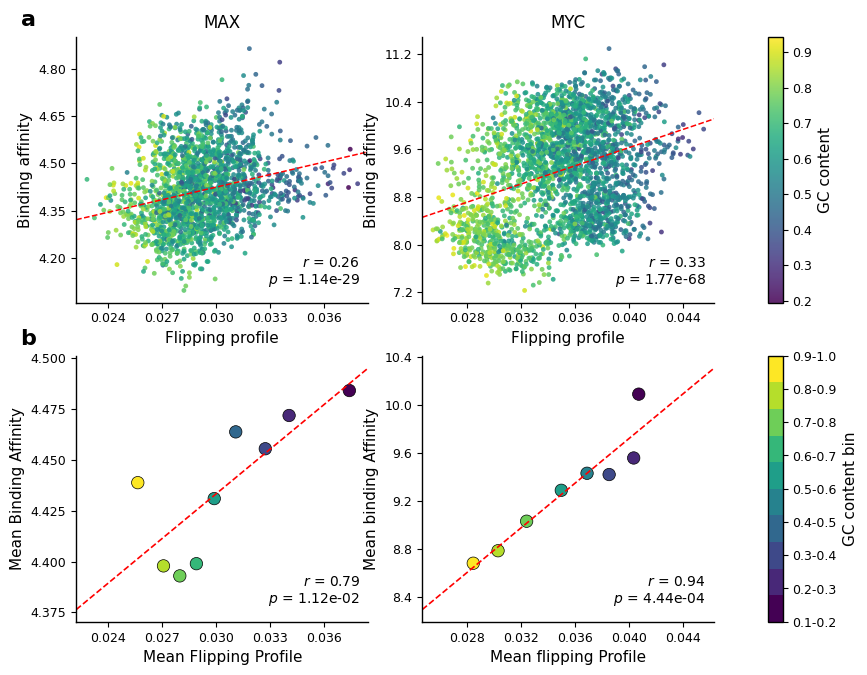

In [46]:
# Generate GC plot
gc_bins = np.linspace(0, 1, 11)
gc_labels = [f"{gc_bins[i]:.1f}-{gc_bins[i+1]:.1f}" for i in range(10)]

plot_feature_vs_flip(
    panset=panset,
    feature_func=gc_content,
    feature_name="GC",
    feature_label="GC content",
    bins=gc_bins,
    bin_ticklabels=gc_labels,
    save_prefix="binding_affinity_flip_profile"
)

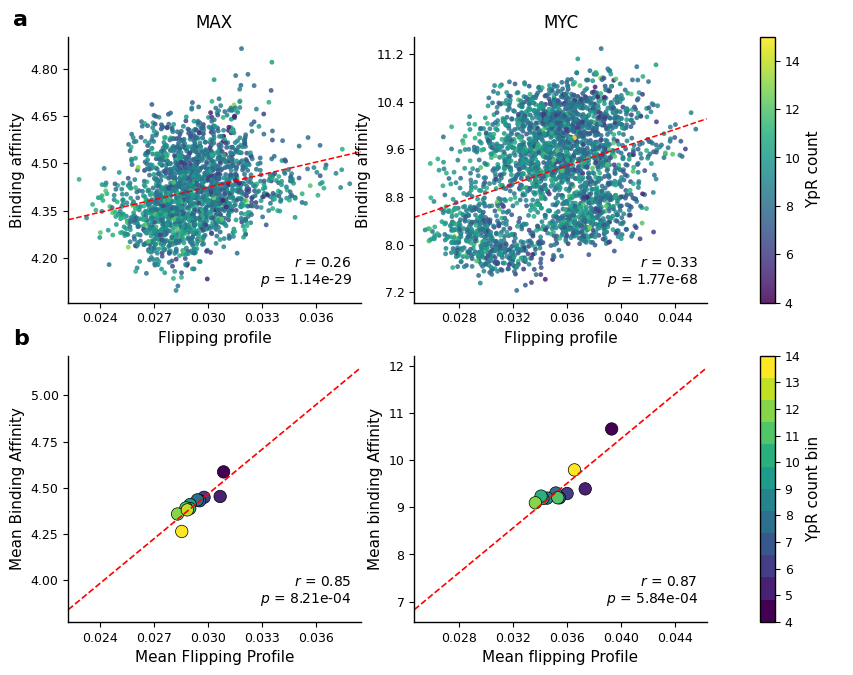

In [47]:
# Generate YpR plot
all_ypr = []
for tf in ["max", "myc"]:
    for seq_id in panset[tf]:
        if panset[tf][seq_id]["strong_motif_binary"] == 1:
            all_ypr.append(count_ypr(panset[tf][seq_id]["seq"]))

ypr_min = int(min(all_ypr))
ypr_max = int(max(all_ypr))
ypr_bins = np.arange(ypr_min, ypr_max + 2) - 0.5
ypr_labels = [str(i) for i in range(ypr_min, ypr_max + 1)]

plot_feature_vs_flip(
    panset=panset,
    feature_func=count_ypr,
    feature_name="YpR",
    feature_label="YpR count",
    bins=ypr_bins,
    bin_ticklabels=ypr_labels,
    save_prefix="binding_affinity_flip_profile"
)



## Pentamer comparison

In [48]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.stats import pearsonr, spearmanr

PANSET_PATH = "../../DNAbreathing/data/gcPBM_data/panset.pkl"
MAX_FEATURE_PATH = "../../DNAbreathing/data/gcPBM_features/compiled_bubble_data/max.pkl"
MYC_FEATURE_PATH = "../../DNAbreathing/data/gcPBM_features/compiled_bubble_data/myc.pkl"
SHAPE_PATH = "../../DNAbreathing/data/dnashape/shape_pentamer.tsv"

Y_SLICE = 10
Z_SLICE = 6
USE_STRONG_MOTIF_ONLY = False

COMP = str.maketrans("ACGT", "TGCA")

def revcomp(seq):
    return seq.translate(COMP)[::-1]

def canonical_pentamer(kmer):
    rc = revcomp(kmer)
    return min(kmer, rc)

def all_512_canonical_pentamers():
    return sorted({canonical_pentamer("".join(p)) for p in product("ACGT", repeat=5)})

def collapse_partitions(raw_dict):
    first_val = next(iter(raw_dict.values()))
    if isinstance(first_val, dict) and "seq" not in first_val:
        out = {}
        for part in raw_dict.values():
            out.update(part)
        return out
    return raw_dict.copy()

with open(PANSET_PATH, "rb") as f:
    panset = pickle.load(f)

with open(MAX_FEATURE_PATH, "rb") as f:
    max_features = pickle.load(f)

with open(MYC_FEATURE_PATH, "rb") as f:
    myc_features = pickle.load(f)

In [50]:
def build_occurrence_table(panset, feature_dict, tf_name, y_slice=10, z_slice=6, use_strong_motif_only=False):
    raw = collapse_partitions(panset[tf_name])
    rows = []

    for seq_id, rec in raw.items():
        if use_strong_motif_only and rec.get("strong_motif_binary", 0) != 1:
            continue

        seq = rec["seq"].upper()
        fdict = feature_dict[str(seq_id)]

        flipping = np.asarray(fdict["flip"][4:40], dtype=float) / 80000.0
        bubble = np.asarray(fdict["bubbles"][4:40, y_slice, z_slice], dtype=float) / 80000.0

        if len(seq) != 36 or len(flipping) != 36 or len(bubble) != 36:
            continue

        for i in range(len(seq) - 4):
            pent = seq[i:i+5]
            if set(pent) - set("ACGT"):
                continue

            center = i + 2
            rows.append({
                "tf": tf_name,
                "pentamer_512": canonical_pentamer(pent),
                "flip_value": float(flipping[center]),
                "bubble_value": float(bubble[center]),
            })

    return pd.DataFrame(rows)

max_occ_df = build_occurrence_table(
    panset, max_features, "max",
    y_slice=Y_SLICE, z_slice=Z_SLICE,
    use_strong_motif_only=USE_STRONG_MOTIF_ONLY
)

myc_occ_df = build_occurrence_table(
    panset, myc_features, "myc",
    y_slice=Y_SLICE, z_slice=Z_SLICE,
    use_strong_motif_only=USE_STRONG_MOTIF_ONLY
)

combined_occ_df = pd.concat([max_occ_df, myc_occ_df], ignore_index=True)

combined_512_df = (
    combined_occ_df
    .groupby("pentamer_512")
    .agg(
        n_occurrences=("pentamer_512", "size"),
        n_max=("tf", lambda x: (x == "max").sum()),
        n_myc=("tf", lambda x: (x == "myc").sum()),
        flip_mean=("flip_value", "mean"),
        flip_sd=("flip_value", "std"),
        bubble_mean=("bubble_value", "mean"),
        bubble_sd=("bubble_value", "std"),
    )
    .reset_index()
)

combined_512_df = pd.DataFrame({"pentamer_512": all_512_canonical_pentamers()}).merge(
    combined_512_df, on="pentamer_512", how="left"
)

print("Observed pentamers:", combined_512_df["n_occurrences"].fillna(0).gt(0).sum(), "/ 512")
display(combined_512_df.head())

Observed pentamers: 512 / 512


,pentamer_512,n_occurrences,n_max,n_myc,flip_mean,flip_sd,bubble_mean,bubble_sd
0,AAAAA,841,468,373,0.174323,0.006899,0.000294,0.001104
1,AAAAC,661,356,305,0.162857,0.005537,0.000191,0.000813
2,AAAAG,718,385,333,0.162481,0.006115,0.000226,0.001065
3,AAAAT,540,304,236,0.174444,0.007410,0.000251,0.001049
4,AAACA,954,511,443,0.149201,0.005289,0.000219,0.000932


In [51]:
shape_df = pd.read_csv(SHAPE_PATH, sep="\t")

shape_df = shape_df[
    shape_df["Pentamer"].notna() &
    (shape_df["Pentamer"].astype(str).str.len() == 5)
].copy()

shape_df["Pentamer"] = shape_df["Pentamer"].str.upper()
shape_df["pentamer_512"] = shape_df["Pentamer"].apply(canonical_pentamer)

shape_512_df = (
    shape_df
    .groupby("pentamer_512", as_index=False)
    .agg(MGW=("MGW", "mean"))
)

combined_vs_mgw = combined_512_df.merge(shape_512_df, on="pentamer_512", how="inner")

def is_ypr(pentamer):
    # center is the first letter of the dinucleotide
    # for a pentamer, that means positions 3-4 (0-based [2:4])
    return pentamer[2:4] in {"TA", "CG"}

combined_vs_mgw["YpR"] = combined_vs_mgw["pentamer_512"].apply(is_ypr)
combined_vs_mgw["group"] = combined_vs_mgw["YpR"].map({True: "YpR", False: "other"})

print("Merged rows:", combined_vs_mgw.shape[0])
display(combined_vs_mgw.head())

Merged rows: 512


,pentamer_512,n_occurrences,n_max,n_myc,flip_mean,flip_sd,bubble_mean,bubble_sd,MGW,YpR,group
0,AAAAA,841,468,373,0.174323,0.006899,0.000294,0.001104,3.38,False,other
1,AAAAC,661,356,305,0.162857,0.005537,0.000191,0.000813,4.05,False,other
2,AAAAG,718,385,333,0.162481,0.006115,0.000226,0.001065,3.68,False,other
3,AAAAT,540,304,236,0.174444,0.007410,0.000251,0.001049,3.63,False,other
4,AAACA,954,511,443,0.149201,0.005289,0.000219,0.000932,4.65,False,other


In [52]:
# -----------------------------
# load shape table
# -----------------------------
shape_df = pd.read_csv(SHAPE_PATH, sep="\t")

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}\nAvailable columns: {list(df.columns)}")

pent_col  = pick_col(shape_df, ["Pentamer"])
mgw_col   = pick_col(shape_df, ["MGW"])
prot_col  = pick_col(shape_df, ["ProT"])

roll1_col = pick_col(shape_df, ["Roll1", "roll1", "Roll_1", "roll_1"])
roll2_col = pick_col(shape_df, ["Roll2", "roll2", "Roll_2", "roll_2"])
helt1_col = pick_col(shape_df, ["HelT1", "helt1", "HelT_1", "helt_1"])
helt2_col = pick_col(shape_df, ["HelT2", "helt2", "HelT_2", "helt_2"])

shape_df = shape_df[
    shape_df[pent_col].notna() &
    (shape_df[pent_col].astype(str).str.len() == 5)
].copy()

shape_df[pent_col] = shape_df[pent_col].str.upper()
shape_df["pentamer_512"] = shape_df[pent_col].apply(canonical_pentamer)

# center values for Roll and HelT
shape_df["Roll_center"] = (
    pd.to_numeric(shape_df[roll1_col], errors="coerce") +
    pd.to_numeric(shape_df[roll2_col], errors="coerce")
) / 2.0

shape_df["HelT_center"] = (
    pd.to_numeric(shape_df[helt1_col], errors="coerce") +
    pd.to_numeric(shape_df[helt2_col], errors="coerce")
) / 2.0

shape_512_df = (
    shape_df
    .groupby("pentamer_512", as_index=False)
    .agg(
        MGW=(mgw_col, "mean"),
        ProT=(prot_col, "mean"),
        Roll_center=("Roll_center", "mean"),
        HelT_center=("HelT_center", "mean"),
    )
)

combined_vs_shape = combined_512_df.merge(shape_512_df, on="pentamer_512", how="inner")

# -----------------------------
# highlight classes
# -----------------------------
def center_dinuc(pentamer):
    return pentamer[2:4]

def is_ypr_custom(pentamer):
    return center_dinuc(pentamer) in {"TA", "CG"}

def is_tpa(pentamer):
    return center_dinuc(pentamer) == "TA"

def is_cpg(pentamer):
    return center_dinuc(pentamer) == "CG"

def is_rpr(pentamer):
    d = center_dinuc(pentamer)
    return (d[0] in "AG") and (d[1] in "AG")

def is_ypy(pentamer):
    d = center_dinuc(pentamer)
    return (d[0] in "CT") and (d[1] in "CT")

combined_vs_shape["YpR"] = combined_vs_shape["pentamer_512"].apply(is_ypr_custom)
combined_vs_shape["TpA"] = combined_vs_shape["pentamer_512"].apply(is_tpa)
combined_vs_shape["CpG"] = combined_vs_shape["pentamer_512"].apply(is_cpg)
combined_vs_shape["RpR"] = combined_vs_shape["pentamer_512"].apply(is_rpr)
combined_vs_shape["YpY"] = combined_vs_shape["pentamer_512"].apply(is_ypy)

print("Merged rows:", combined_vs_shape.shape[0])
display(combined_vs_shape.head())

Merged rows: 512


,pentamer_512,n_occurrences,n_max,n_myc,flip_mean,flip_sd,bubble_mean,bubble_sd,MGW,ProT,Roll_center,HelT_center,YpR,TpA,CpG,RpR,YpY
0,AAAAA,841,468,373,0.174323,0.006899,0.000294,0.001104,3.38,-16.51,-5.070,37.875,False,False,False,True,False
1,AAAAC,661,356,305,0.162857,0.005537,0.000191,0.000813,4.05,-14.47,-4.210,37.040,False,False,False,True,False
2,AAAAG,718,385,333,0.162481,0.006115,0.000226,0.001065,3.68,-14.68,-5.350,37.100,False,False,False,True,False
3,AAAAT,540,304,236,0.174444,0.007410,0.000251,0.001049,3.63,-14.89,-4.340,37.305,False,False,False,True,False
4,AAACA,954,511,443,0.149201,0.005289,0.000219,0.000932,4.65,-13.05,-2.935,35.905,False,False,False,False,False


Auto-detected dinucleotide slice from pentamer_512: str[1:3]
Agreement with existing 'group': 1.000

Plot-class counts:
plot_class
Other    392
YpR       60
CpG       32
TpA       28
Name: count, dtype: int64

Flipping vs MGW
N = 512
Pearson r  = -0.0904, p = 4.099e-02
Spearman r = -0.0591, p = 1.820e-01


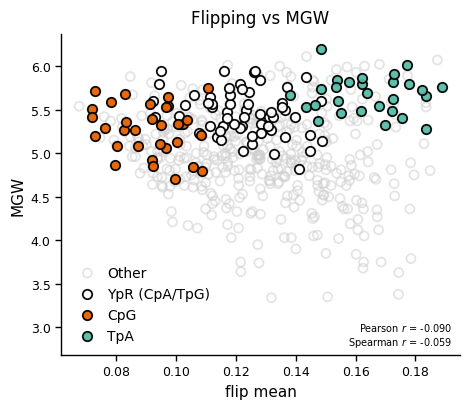


Bubble vs MGW
N = 512
Pearson r  = -0.0807, p = 6.796e-02
Spearman r = -0.0216, p = 6.263e-01


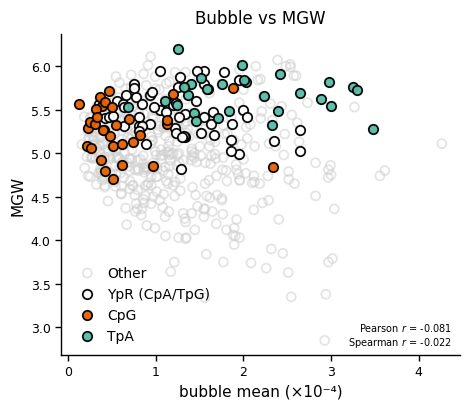


Flipping vs ProT
N = 512
Pearson r  = -0.6929, p = 1.795e-74
Spearman r = -0.7077, p = 5.503e-79


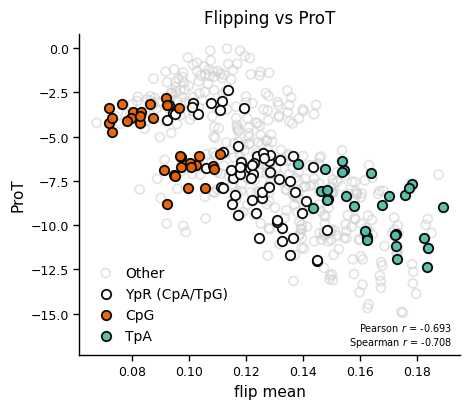


Bubble vs ProT
N = 512
Pearson r  = -0.4743, p = 4.495e-30
Spearman r = -0.4725, p = 7.902e-30


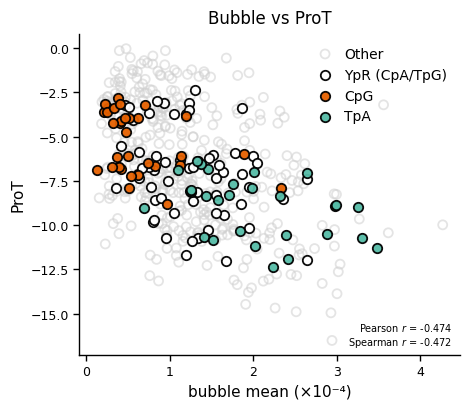


Flipping vs Roll_center
N = 512
Pearson r  = -0.1752, p = 6.760e-05
Spearman r = -0.1724, p = 8.859e-05


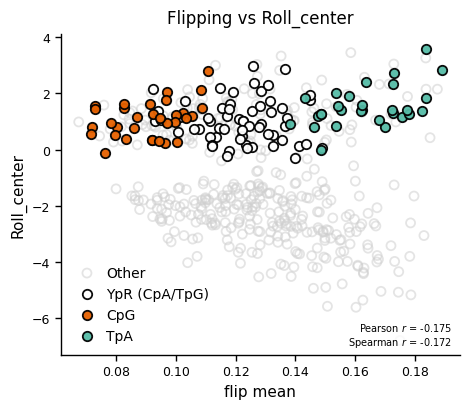


Bubble vs Roll_center
N = 512
Pearson r  = -0.0392, p = 3.764e-01
Spearman r = -0.0227, p = 6.083e-01


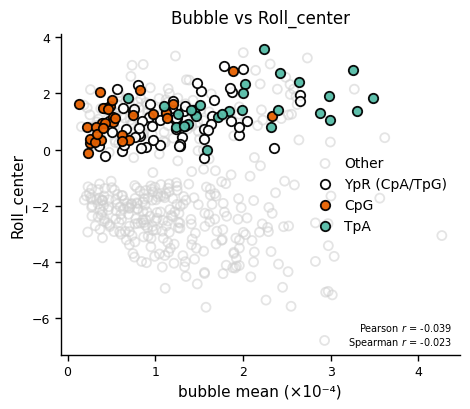


Flipping vs HelT_center
N = 512
Pearson r  = 0.1824, p = 3.310e-05
Spearman r = 0.1432, p = 1.159e-03


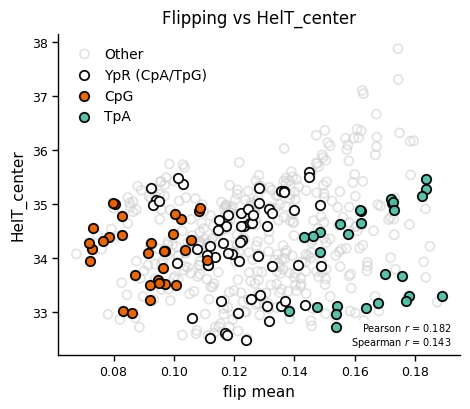


Bubble vs HelT_center
N = 512
Pearson r  = 0.1868, p = 2.107e-05
Spearman r = 0.1611, p = 2.513e-04


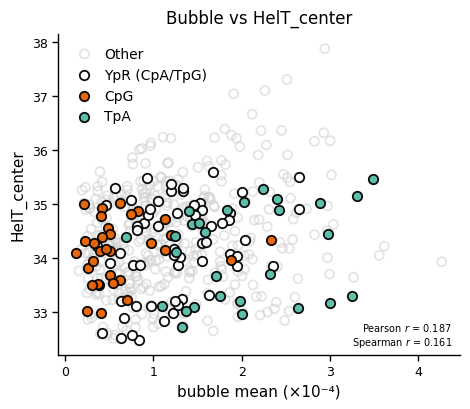


Summary
       subset feature_col   shape_col   n  pearson_r    pearson_p  spearman_r   spearman_p
All pentamers   flip_mean         MGW 512  -0.090353 4.098910e-02   -0.059076 1.819956e-01
All pentamers bubble_mean         MGW 512  -0.080732 6.795937e-02   -0.021572 6.262656e-01
All pentamers   flip_mean        ProT 512  -0.692932 1.795490e-74   -0.707725 5.502713e-79
All pentamers bubble_mean        ProT 512  -0.474255 4.495098e-30   -0.472454 7.902445e-30
All pentamers   flip_mean Roll_center 512  -0.175161 6.759678e-05   -0.172360 8.858694e-05
All pentamers bubble_mean Roll_center 512  -0.039171 3.764250e-01   -0.022703 6.082801e-01
All pentamers   flip_mean HelT_center 512   0.182356 3.309875e-05    0.143184 1.159214e-03
All pentamers bubble_mean HelT_center 512   0.186769 2.106892e-05    0.161128 2.512887e-04


In [55]:
# ============================================================
# Plot breathing feature vs MGW using the same plot type/style
# as before:
#   Other          = gray hollow circles
#   YpR CpA/TpG    = black hollow circles
#   CpG            = orange filled circles, black edge
#   TpA            = teal filled circles, black edge
# ============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, gaussian_kde


# ------------------------------------------------------------
# DataFrame fallback
# ------------------------------------------------------------
if "combined_vs_shape" not in globals():
    if "combined_vs_mgw" in globals():
        combined_vs_shape = combined_vs_mgw.copy()
    else:
        raise NameError(
            "Expected a DataFrame named combined_vs_shape or combined_vs_mgw."
        )


# ------------------------------------------------------------
# Plot style matching the previous plot type
# ------------------------------------------------------------
CLASS_ORDER = ["Other", "YpR", "CpG", "TpA"]

CLASS_LABELS = {
    "Other": "Other",
    "YpR": "YpR (CpA/TpG)",
    "CpG": "CpG",
    "TpA": "TpA",
}

SCATTER_STYLES = {
    "Other": dict(
        s=42,
        alpha=0.55,
        facecolors="none",
        edgecolors="#CFCFCF",
        linewidth=1.3,
        marker="o",
        zorder=1,
    ),
    "YpR": dict(
        s=46,
        alpha=0.95,
        facecolors="white",
        edgecolors="black",
        linewidth=1.3,
        marker="o",
        zorder=4,
    ),
    "CpG": dict(
        s=46,
        alpha=0.95,
        facecolors="#E66100",
        edgecolors="black",
        linewidth=1.3,
        marker="o",
        zorder=5,
    ),
    "TpA": dict(
        s=46,
        alpha=0.95,
        facecolors="#55BCA7",
        edgecolors="black",
        linewidth=1.3,
        marker="o",
        zorder=5,
    ),
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def _sanitize_name(x):
    x = str(x)
    x = re.sub(r"[^A-Za-z0-9]+", "_", x)
    x = x.strip("_")
    return x or "plot"


def _class_from_step(step):
    """
    Classify a dinucleotide step.

    CpG and TpA are separated.
    Remaining YpR steps are CpA/TpG, i.e. CA or TG.
    """
    step = str(step).upper()

    if step == "CG":
        return "CpG"
    if step == "TA":
        return "TpA"
    if step in {"CA", "TG"}:
        return "YpR"

    return "Other"


def _normalize_group_value(v):
    if pd.isna(v):
        return np.nan

    s = str(v).strip().lower()

    if s in {"other", "others", "non-ypr", "non_ypr", "non ypr"}:
        return "Other"

    if "cpg" in s or s == "cg":
        return "CpG"

    if "tpa" in s or s == "ta":
        return "TpA"

    if "ypr" in s or "cpa" in s or "tpg" in s or s in {"ca", "tg"}:
        return "YpR"

    return np.nan


def add_missing_shape_plot_columns(
    df,
    pentamer_col="pentamer_512",
    group_col="group",
    step_slice=None,
    verbose=True,
):
    """
    Adds:
        valid_pentamer
        plot_class
        has_ypr

    If step_slice is None, the code auto-detects which dinucleotide
    in pentamer_512 agrees best with the existing group column.
    """
    out = df.copy()

    if pentamer_col not in out.columns:
        raise ValueError(f"Missing required pentamer column: {pentamer_col}")

    seq = out[pentamer_col].astype(str).str.upper()

    out["valid_pentamer"] = seq.str.fullmatch(r"[ACGT]{5}").fillna(False)

    if step_slice is not None:
        if (
            not isinstance(step_slice, tuple)
            or len(step_slice) != 2
            or step_slice[0] < 0
            or step_slice[1] > 5
            or step_slice[0] >= step_slice[1]
        ):
            raise ValueError(
                "step_slice must be a tuple like (0, 2), (1, 3), (2, 4), or (3, 5)."
            )
        best_slice = step_slice

    else:
        best_slice = (1, 3)

        if group_col in out.columns:
            gclass = out[group_col].map(_normalize_group_value)
            known = gclass.notna() & out["valid_pentamer"]

            if known.sum() > 0:
                group_is_ypr = gclass.isin(["YpR", "CpG", "TpA"])

                best_score = -np.inf
                candidate_slices = [(0, 2), (1, 3), (2, 4), (3, 5)]

                for a, b in candidate_slices:
                    pred_class = seq.str.slice(a, b).map(_class_from_step)
                    pred_is_ypr = pred_class.isin(["YpR", "CpG", "TpA"])

                    score = (pred_is_ypr[known] == group_is_ypr[known]).mean()

                    if score > best_score:
                        best_score = score
                        best_slice = (a, b)

                if verbose:
                    print(
                        f"Auto-detected dinucleotide slice from {pentamer_col}: "
                        f"str[{best_slice[0]}:{best_slice[1]}]"
                    )
                    print(f"Agreement with existing {group_col!r}: {best_score:.3f}")

    a, b = best_slice

    out["plot_class"] = seq.str.slice(a, b).map(_class_from_step)
    out.loc[~out["valid_pentamer"], "plot_class"] = "Other"

    out["has_ypr"] = out["plot_class"].isin(["YpR", "CpG", "TpA"])

    if group_col not in out.columns:
        out[group_col] = np.where(out["has_ypr"], "YpR", "other")

    if verbose:
        print("\nPlot-class counts:")
        print(
            out["plot_class"]
            .value_counts(dropna=False)
            .reindex(CLASS_ORDER, fill_value=0)
        )

    return out


def _safe_corr(x, y, method="pearson"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan

    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15:
        return np.nan, np.nan

    if method == "pearson":
        return pearsonr(x, y)
    if method == "spearman":
        return spearmanr(x, y)

    raise ValueError("method must be 'pearson' or 'spearman'")


def _format_p(p):
    if pd.isna(p):
        return "NA"
    return f"{p:.3e}"


def _feature_label_and_plot_values(sub, feature_col):
    x = sub[feature_col].to_numpy(dtype=float)

    if feature_col == "bubble_mean":
        return x * 1e4, "bubble mean (×10⁻⁴)"

    if feature_col == "bubble_max":
        return x * 1e4, "maximum bubble probability (×10⁻⁴)"

    if feature_col == "flip_mean":
        return x, "flip mean"

    if feature_col == "flip_max":
        return x, "maximum flipping probability"

    return x, feature_col.replace("_", " ")


def _feature_title_name(feature_col):
    if feature_col == "flip_mean":
        return "Flipping"
    if feature_col == "bubble_mean":
        return "Bubble"
    if feature_col == "flip_max":
        return "Maximum flipping"
    if feature_col == "bubble_max":
        return "Maximum bubble"
    return feature_col.replace("_", " ").title()


def _make_density_plot(
    sub,
    feature_col,
    shape_col,
    title,
    out_prefix,
    out_dir,
    show=True,
):
    x1 = sub[feature_col].to_numpy(dtype=float)
    x2 = sub[shape_col].to_numpy(dtype=float)

    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]

    if len(x1) < 3 or len(x2) < 3:
        print(f"Skipping density plot for {title}: not enough finite values.")
        return None, None

    if np.std(x1) < 1e-15 or np.std(x2) < 1e-15:
        print(f"Skipping density plot for {title}: not enough variation.")
        return None, None

    x1z = (x1 - np.mean(x1)) / np.std(x1)
    x2z = (x2 - np.mean(x2)) / np.std(x2)

    xmin = min(x1z.min(), x2z.min())
    xmax = max(x1z.max(), x2z.max())
    pad = 0.2 * (xmax - xmin if xmax > xmin else 1.0)

    xs = np.linspace(xmin - pad, xmax + pad, 500)

    kde1 = gaussian_kde(x1z)
    kde2 = gaussian_kde(x2z)

    fig, ax = plt.subplots(figsize=(4.8, 4.2))

    ax.plot(
        xs,
        kde1(xs),
        linewidth=2.2,
        label=feature_col.replace("_", " "),
        color="#0072B2",
    )
    ax.plot(
        xs,
        kde2(xs),
        linewidth=2.2,
        label=shape_col,
        color="#D55E00",
    )

    ax.set_xlabel("z-scored value")
    ax.set_ylabel("Density")
    ax.set_title(f"Density overlap: {title}", pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=4, width=1)
    ax.legend(frameon=False, loc="best")

    plt.tight_layout()

    pdf_path = Path(out_dir) / f"{out_prefix}_density.pdf"
    png_path = Path(out_dir) / f"{out_prefix}_density.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return str(pdf_path), str(png_path)


def compare_feature_vs_shape_same_plot_type(
    df,
    feature_col,
    shape_col="MGW",
    title=None,
    out_prefix=None,
    out_dir="shape_plots",
    pentamer_col="pentamer_512",
    group_col="group",
    step_slice=None,
    only_ypr=False,
    make_density=False,
    show=True,
):
    """
    Publication-style scatter plot using the same plot type/style as before.

    By default, this makes the scatter plot shown in your screenshot.
    Set make_density=True to also save/show the density-overlap plot.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    work = add_missing_shape_plot_columns(
        df,
        pentamer_col=pentamer_col,
        group_col=group_col,
        step_slice=step_slice,
        verbose=False,
    )

    required_cols = [
        feature_col,
        shape_col,
        pentamer_col,
        "plot_class",
        "valid_pentamer",
        "has_ypr",
    ]

    missing = [c for c in required_cols if c not in work.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    sub = work[required_cols].copy()

    sub[feature_col] = pd.to_numeric(sub[feature_col], errors="coerce")
    sub[shape_col] = pd.to_numeric(sub[shape_col], errors="coerce")

    sub = sub.dropna(subset=[feature_col, shape_col]).copy()
    sub = sub[sub["valid_pentamer"]].copy()

    if only_ypr:
        sub = sub[sub["has_ypr"]].copy()

    if len(sub) == 0:
        raise ValueError(
            f"No usable rows for {feature_col} vs {shape_col}. "
            "Check missing values, valid pentamers, and only_ypr filtering."
        )

    r_p, p_p = _safe_corr(sub[feature_col], sub[shape_col], method="pearson")
    r_s, p_s = _safe_corr(sub[feature_col], sub[shape_col], method="spearman")

    x_plot, xlabel = _feature_label_and_plot_values(sub, feature_col)
    sub["_x_plot"] = x_plot

    if title is None:
        prefix = "YpR only: " if only_ypr else ""
        title = f"{prefix}{_feature_title_name(feature_col)} vs {shape_col}"

    if out_prefix is None:
        subset_name = "ypr_only" if only_ypr else "all"
        out_prefix = _sanitize_name(f"{subset_name}_{feature_col}_vs_{shape_col}")

    print("\n" + "=" * 70)
    print(title)
    print(f"N = {len(sub)}")
    print(f"Pearson r  = {r_p:.4f}, p = {_format_p(p_p)}")
    print(f"Spearman r = {r_s:.4f}, p = {_format_p(p_s)}")

    # --------------------------------------------------------
    # Scatter plot matching the previous plot type
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(4.8, 4.2))

    for cls in CLASS_ORDER:
        if only_ypr and cls == "Other":
            continue

        tmp = sub[sub["plot_class"] == cls]

        if tmp.empty:
            continue

        ax.scatter(
            tmp["_x_plot"],
            tmp[shape_col],
            label=CLASS_LABELS[cls],
            **SCATTER_STYLES[cls],
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(shape_col)
    ax.set_title(title, pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=4, width=1)

    ax.legend(
        frameon=False,
        loc="best",
        handletextpad=0.4,
        scatterpoints=1,
    )

    ax.text(
        0.98,
        0.02,
        f"Pearson $r$ = {r_p:.3f}\nSpearman $r$ = {r_s:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
        ),
    )

    plt.tight_layout()

    scatter_pdf = out_dir / f"{out_prefix}_scatter.pdf"
    scatter_png = out_dir / f"{out_prefix}_scatter.png"

    fig.savefig(scatter_pdf, bbox_inches="tight")
    fig.savefig(scatter_png, dpi=600, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    density_pdf = None
    density_png = None

    if make_density:
        density_pdf, density_png = _make_density_plot(
            sub=sub,
            feature_col=feature_col,
            shape_col=shape_col,
            title=title,
            out_prefix=out_prefix,
            out_dir=out_dir,
            show=show,
        )

    return {
        "subset": "YpR only" if only_ypr else "All pentamers",
        "feature_col": feature_col,
        "shape_col": shape_col,
        "n": len(sub),
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s,
        "scatter_pdf": str(scatter_pdf),
        "scatter_png": str(scatter_png),
        "density_pdf": density_pdf,
        "density_png": density_png,
    }


# ============================================================
# Run plots
# ============================================================

OUT_DIR = "shape_plots"

# Change this only if the wrong dinucleotide step is being classified.
# Examples: (0, 2), (1, 3), (2, 4), or (3, 5)
STEP_SLICE = None

# The screenshot is a scatter plot. Keep this False for that plot type.
# Set True only when you also want density-overlap plots.
MAKE_DENSITY = False

# These are the default plots from your previous workflow.
FEATURE_COLS = ["flip_mean", "bubble_mean"]

# Keep MGW only for the same plot type as before.
# Add more columns later, e.g. ["MGW", "ProT", "Roll", "HelT"].
SHAPE_COLS = ["MGW", "ProT", "Roll_center", "HelT_center"]

# Whether to also make YpR-family-only plots.
RUN_YPR_ONLY = True


combined_vs_shape = add_missing_shape_plot_columns(
    combined_vs_shape,
    pentamer_col="pentamer_512",
    group_col="group",
    step_slice=STEP_SLICE,
    verbose=True,
)

existing_features = [c for c in FEATURE_COLS if c in combined_vs_shape.columns]
existing_shapes = [c for c in SHAPE_COLS if c in combined_vs_shape.columns]

if not existing_features:
    raise ValueError(
        f"None of the requested feature columns were found: {FEATURE_COLS}\n"
        f"Available columns:\n{list(combined_vs_shape.columns)}"
    )

if not existing_shapes:
    raise ValueError(
        f"None of the requested shape columns were found: {SHAPE_COLS}\n"
        f"Available columns:\n{list(combined_vs_shape.columns)}"
    )

results = []

for shape_col in existing_shapes:
    for feature_col in existing_features:

        results.append(
            compare_feature_vs_shape_same_plot_type(
                combined_vs_shape,
                feature_col=feature_col,
                shape_col=shape_col,
                title=f"{_feature_title_name(feature_col)} vs {shape_col}",
                out_prefix=f"combined_{feature_col}_vs_{shape_col}",
                out_dir=OUT_DIR,
                pentamer_col="pentamer_512",
                group_col="group",
                step_slice=STEP_SLICE,
                only_ypr=False,
                make_density=MAKE_DENSITY,
                show=True,
            )
        )

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Summary")
print(
    results_df[
        [
            "subset",
            "feature_col",
            "shape_col",
            "n",
            "pearson_r",
            "pearson_p",
            "spearman_r",
            "spearman_p",
        ]
    ].to_string(index=False)
)